# 04 — Fine-tuning do BERTimbau (Mão na Roda) — v2

**Equipe:** Diego Spagnuolo Sugai, Kauê Henrique Matias Alves, Leonardo Moreira dos Santos, Victor Maki Tarcha
**Orientador:** Prof. Dr. Ivan Carlos Alcântara de Oliveira

Correções em relação à v1:
- Nomes das classes alinhados com os do dataset real
- Split ajustado para 80/10/10 (mais adequado para 169 amostras)
- Caminho do dataset verificado

---
## Seção 0 — Setup

In [ ]:
!pip install -q "transformers>=4.40,<5.0" "accelerate>=0.30" "datasets>=2.18" "scikit-learn>=1.3" "matplotlib>=3.7" "seaborn>=0.13" 2>&1 | tail -1
print("Dependências OK.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.0 MB/s eta 0:00:00
Dependências OK.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

BASE = Path('/content/drive/MyDrive/Agente Mecânico')
assert BASE.exists(), f'Pasta não encontrada: {BASE}'

DATASET_PATH   = BASE / 'Dataset_Estruturado' / 'dataset_mao_na_roda_v2.xlsx'
MODELO_DIR     = BASE / 'modelos' / 'bertimbau_mao_na_roda'
RESULTADOS_DIR = BASE / 'resultados'
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)
MODELO_DIR.mkdir(parents=True, exist_ok=True)

assert DATASET_PATH.exists(), f'Dataset não encontrado: {DATASET_PATH}'
print(f'Dataset:    {DATASET_PATH}')
print(f'Modelos:    {MODELO_DIR}')
print(f'Resultados: {RESULTADOS_DIR}')

Dataset:    /content/drive/MyDrive/Agente Mecânico/Dataset_Estruturado/dataset_mao_na_roda_v2.xlsx
Modelos:    /content/drive/MyDrive/Agente Mecânico/modelos/bertimbau_mao_na_roda
Resultados: /content/drive/MyDrive/Agente Mecânico/resultados


In [ ]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device: {torch.cuda.get_device_name(0)}')
    print(f'Memória: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch: 2.10.0+cu128
CUDA: True
Device: Tesla T4
Memória: 15.6 GB


---
## Seção 1 — Carregamento do dataset

Split 80/10/10 (treino/validação/teste). Mais adequado para 169 amostras do que o 70/15/15 anterior.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_excel(DATASET_PATH)

# Usar falha_descricao para construir o dicionário de classes diretamente do dataset
# Assim os nomes nunca ficam desalinhados.
classes_df = (df[['falha_label','falha_descricao']]
              .drop_duplicates()
              .sort_values('falha_label')
              .groupby('falha_label')['falha_descricao']
              .first())

CLASSES = classes_df.to_dict()
N_CLASSES = len(CLASSES)

print(f'Total: {len(df)} relatos | Classes: {N_CLASSES}')
print()
print('Classes detectadas no dataset:')
for k, v in CLASSES.items():
    n = (df['falha_label'] == k).sum()
    print(f'  {k}: {v}  ({n} amostras)')

Total: 169 relatos | Classes: 10

Classes detectadas no dataset:
  0: Bateria/Sistema Elétrico  (17 amostras)
  1: Sistema de Freios  (19 amostras)
  2: Superaquecimento do Motor  (18 amostras)
  3: Suspensão/Amortecedores  (17 amostras)
  4: Sistema de Transmissão/Câmbio  (17 amostras)
  5: Vazamento de Óleo  (16 amostras)
  6: Sistema de Arrefecimento  (15 amostras)
  7: Pneu/Roda  (17 amostras)
  8: Sistema de Injeção/Combustível  (18 amostras)
  9: Sistema de Escapamento  (15 amostras)


In [ ]:
SEED_SPLIT = 42

# 80% treino, 20% temp
df_treino, df_temp = train_test_split(
    df, test_size=0.20,
    stratify=df['falha_label'],
    random_state=SEED_SPLIT,
)
# 50% de temp → validação, 50% → teste  (= 10% / 10% do total)
df_val, df_teste = train_test_split(
    df_temp, test_size=0.50,
    stratify=df_temp['falha_label'],
    random_state=SEED_SPLIT,
)

print(f'Treino: {len(df_treino)} | Validação: {len(df_val)} | Teste: {len(df_teste)}')

df_treino.to_csv(RESULTADOS_DIR / 'split_treino.csv', index=False)
df_val.to_csv(RESULTADOS_DIR / 'split_val.csv', index=False)
df_teste.to_csv(RESULTADOS_DIR / 'split_teste.csv', index=False)
print('Splits salvos.')

Treino: 135 | Validação: 17 | Teste: 17
Splits salvos.


---
## Seção 2 — Tokenização

In [ ]:
from transformers import AutoTokenizer
from datasets import Dataset

NOME_MODELO = 'neuralmind/bert-base-portuguese-cased'
MAX_LENGTH  = 128

tokenizer = AutoTokenizer.from_pretrained(NOME_MODELO)

TEM_VARIACAO_LING = 'variacao_linguistica' in df.columns
COLS_BASE = ['relato', 'falha_label'] + (['variacao_linguistica'] if TEM_VARIACAO_LING else [])
print(f'Colunas usadas: {COLS_BASE}')
print(f'Análise por variação linguística: {TEM_VARIACAO_LING}')

def df_para_dataset(df_in):
    ds = Dataset.from_pandas(df_in[COLS_BASE].reset_index(drop=True))
    ds = ds.rename_column('falha_label', 'labels')
    def tok(batch):
        return tokenizer(batch['relato'], truncation=True,
                         padding='max_length', max_length=MAX_LENGTH)
    return ds.map(tok, batched=True)

ds_treino = df_para_dataset(df_treino)
ds_val    = df_para_dataset(df_val)
ds_teste  = df_para_dataset(df_teste)

print(f'Tokenização: treino={len(ds_treino)}, val={len(ds_val)}, teste={len(ds_teste)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

Colunas usadas: ['relato', 'falha_label', 'variacao_linguistica']
Análise por variação linguística: True


Map:   0%|          | 0/135 [00:00<?, ? examples/s]

Map:   0%|          | 0/17 [00:00<?, ? examples/s]

Map:   0%|          | 0/17 [00:00<?, ? examples/s]

Tokenização: treino=135, val=17, teste=17


---
## Seção 3 — Métricas

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'f1_macro':    f1_score(labels, preds, average='macro'),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
        'acc':         accuracy_score(labels, preds),
    }

---
## Seção 4 — Fine-tuning com 3 seeds

Hiperparâmetros: lr=2e-5, batch=16, 5 épocas, early stopping em F1-macro (paciência 2), weight_decay=0.01, warmup_ratio=0.1.

Tempo esperado por seed na T4: 5-10 minutos.

In [ ]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    EarlyStoppingCallback, set_seed,
)
import time

SEEDS = [42, 123, 2024]

def treinar_uma_seed(seed: int):
    print(f'\n{"="*60}\nTREINO — SEED {seed}\n{"="*60}')
    set_seed(seed)

    modelo = AutoModelForSequenceClassification.from_pretrained(
        NOME_MODELO, num_labels=N_CLASSES,
    )

    args = TrainingArguments(
        output_dir=f'/tmp/bert_seed_{seed}',
        num_train_epochs=20,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=5e-5,
        weight_decay=0.01,
        warmup_ratio=0.05,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        save_total_limit=1,
        seed=seed,
        logging_steps=10,
        report_to='none',
        fp16=torch.cuda.is_available(),
    )

    trainer = Trainer(
        model=modelo,
        args=args,
        train_dataset=ds_treino,
        eval_dataset=ds_val,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )

    t0 = time.time()
    trainer.train()
    tempo = time.time() - t0

    mv = trainer.evaluate(ds_val)
    mt = trainer.evaluate(ds_teste)
    mtr = trainer.evaluate(ds_treino)

    preds = trainer.predict(ds_teste)
    y_pred = np.argmax(preds.predictions, axis=-1)
    y_true = preds.label_ids

    res = {
        'seed': seed,
        'tempo_seg': tempo,
        'val':    {'f1_macro': float(mv['eval_f1_macro']),
                   'f1_weighted': float(mv['eval_f1_weighted']),
                   'acc': float(mv['eval_acc'])},
        'teste':  {'f1_macro': float(mt['eval_f1_macro']),
                   'f1_weighted': float(mt['eval_f1_weighted']),
                   'acc': float(mt['eval_acc'])},
        'treino': {'f1_macro': float(mtr['eval_f1_macro']),
                   'acc': float(mtr['eval_acc'])},
        'gap_treino_teste': float(mtr['eval_f1_macro'] - mt['eval_f1_macro']),
        'y_pred_teste': y_pred.tolist(),
        'y_true_teste': y_true.tolist(),
    }

    print(f'  F1-macro Val:  {res["val"]["f1_macro"]:.4f}')
    print(f'  F1-macro Teste:{res["teste"]["f1_macro"]:.4f}')
    print(f'  Acurácia:      {res["teste"]["acc"]:.4f}')
    print(f'  Gap tr-te:     {res["gap_treino_teste"]:.4f}')
    return res, trainer

In [ ]:
resultados = {}
melhor_trainer = None
melhor_f1_val  = -1
melhor_seed    = None

for seed in SEEDS:
    res, trainer = treinar_uma_seed(seed)
    resultados[seed] = res
    if res['val']['f1_macro'] > melhor_f1_val:
        melhor_f1_val = res['val']['f1_macro']
        melhor_trainer = trainer
        melhor_seed = seed

print(f'\nMelhor seed: {melhor_seed} (F1-macro val={melhor_f1_val:.4f})')


TREINO — SEED 42


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Acc
1,No log,2.270738,0.090000,0.105882,0.176471
2,2.327000,2.143267,0.148571,0.174790,0.235294
3,2.185500,1.942440,0.366667,0.431373,0.470588
4,1.896700,1.668974,0.430000,0.476471,0.529412
5,1.537000,1.384507,0.643333,0.668627,0.705882
6,1.114100,1.099940,0.706667,0.752941,0.764706
7,0.796200,0.973037,0.590476,0.655462,0.705882
8,0.508300,0.930808,0.566667,0.627451,0.647059
9,0.340800,0.891415,0.623810,0.694678,0.705882
10,0.217500,0.867848,0.666667,0.745098,0.764706


...

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Acc
1,No log,2.293945,0.021053,0.024768,0.117647
2,2.311200,2.271312,0.021053,0.024768,0.117647
3,2.312600,2.186409,0.028571,0.033613,0.117647
4,2.193200,1.931928,0.453333,0.513725,0.529412
5,1.872500,1.601850,0.580000,0.643137,0.647059
6,1.448900,1.341424,0.720000,0.749020,0.764706
7,1.084600,1.110696,0.723333,0.752941,0.764706
8,0.759600,0.895680,0.657143,0.733894,0.764706
9,0.482900,0.876573,0.766667,0.803922,0.823529
10,0.316700,0.870972,0.666667,0.745098,0.764706


  F1-macro Val:  0.7667
  F1-macro Teste:0.4700
  Acurácia:      0.5882
  Gap tr-te:     0.5300

TREINO — SEED 2024


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Acc
1,No log,2.288948,0.084444,0.099346,0.176471
2,2.319300,2.203010,0.138889,0.150327,0.176471
3,2.241000,1.969267,0.333333,0.372549,0.352941
4,1.991900,1.616498,0.480000,0.545098,0.588235
5,1.533600,1.351764,0.570000,0.631373,0.647059
6,1.144700,1.135168,0.653333,0.690196,0.705882
7,0.848200,1.004883,0.657143,0.733894,0.764706
8,0.565100,0.817577,0.657143,0.733894,0.764706
9,0.377100,0.713530,0.657143,0.733894,0.764706
10,0.231400,0.734551,0.657143,0.733894,0.764706


  F1-macro Val:  0.7667
  F1-macro Teste:0.7633
  Acurácia:      0.8235
  Gap tr-te:     0.2367

Melhor seed: 123 (F1-macro val=0.7667)


---
## Seção 5 — Resultados consolidados

In [ ]:
linhas = []
for seed, r in resultados.items():
    linhas.append({
        'seed': seed,
        'f1_macro_val':   r['val']['f1_macro'],
        'f1_macro_teste': r['teste']['f1_macro'],
        'acc_teste':      r['teste']['acc'],
        'gap_tr_te':      r['gap_treino_teste'],
        'tempo_seg':      r['tempo_seg'],
    })
df_res = pd.DataFrame(linhas)
medias  = df_res.drop(columns=['seed']).mean()
desvios = df_res.drop(columns=['seed']).std()

print('Resultados por seed:')
print(df_res.to_string(index=False))
print()
print('Média ± desvio:')
for col in medias.index:
    print(f'  {col:20s}  {medias[col]:.4f} ± {desvios[col]:.4f}')

df_res.to_csv(RESULTADOS_DIR / 'bertimbau_resultados_seeds.csv', index=False)

Resultados por seed:
 seed  f1_macro_val  f1_macro_teste  acc_teste  gap_tr_te  tempo_seg
   42      0.706667        0.596667   0.705882   0.381456 129.173864
  123      0.766667        0.470000   0.588235   0.530000 200.278245
 2024      0.766667        0.763333   0.823529   0.236667 283.703376

Média ± desvio:
  f1_macro_val          0.7467 ± 0.0346
  f1_macro_teste        0.6100 ± 0.1471
  acc_teste             0.7059 ± 0.1176
  gap_tr_te             0.3827 ± 0.1467
  tempo_seg             204.3852 ± 77.3466


In [ ]:
F1_BASELINE = 0.607

f1_bert = df_res['f1_macro_teste'].mean()
ganho   = f1_bert - F1_BASELINE
print(f'Baseline TF-IDF:          {F1_BASELINE:.4f}')
print(f'BERTimbau (média 3 seeds):{f1_bert:.4f}')
print(f'Ganho absoluto:           {ganho:+.4f} ({ganho/F1_BASELINE*100:+.1f}%)')

Baseline TF-IDF:          0.6070
BERTimbau (média 3 seeds):0.6100
Ganho absoluto:           +0.0030 (+0.5%)


---
## Seção 6 — Matriz de confusão

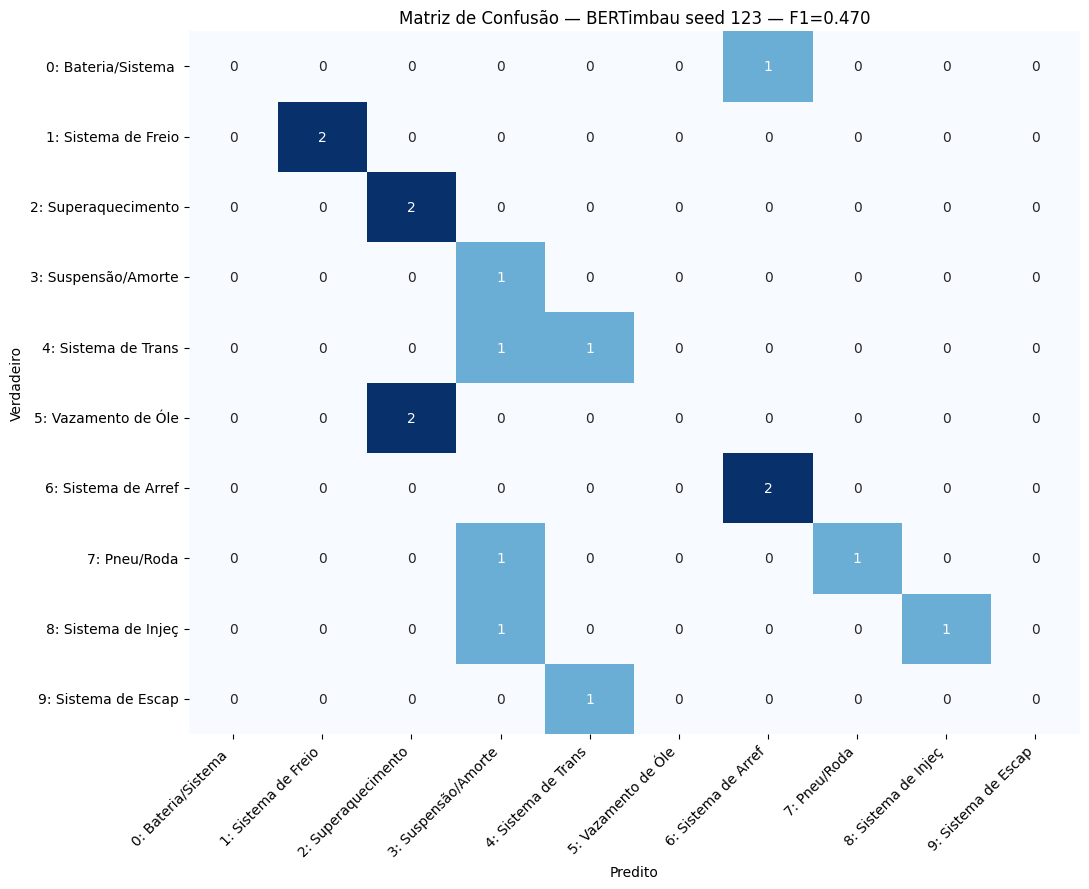

Salva: /content/drive/MyDrive/Agente Mecânico/resultados/bertimbau_matriz_confusao.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

melhor = resultados[melhor_seed]
y_true = np.array(melhor['y_true_teste'])
y_pred = np.array(melhor['y_pred_teste'])

cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
nomes = [f'{k}: {v[:16]}' for k, v in CLASSES.items()]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes, yticklabels=nomes,
            ax=ax, cbar=False)
ax.set_xlabel('Predito')
ax.set_ylabel('Verdadeiro')
ax.set_title(f'Matriz de Confusão — BERTimbau seed {melhor_seed} — F1={melhor["teste"]["f1_macro"]:.3f}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

p = RESULTADOS_DIR / 'bertimbau_matriz_confusao.png'
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salva: {p}')

In [ ]:
rel = classification_report(
    y_true, y_pred,
    target_names=[CLASSES[i] for i in range(N_CLASSES)],
    digits=3, zero_division=0,
)
print(rel)
with open(RESULTADOS_DIR / 'bertimbau_classification_report.txt', 'w', encoding='utf-8') as f:
    f.write(rel)

                                precision    recall  f1-score   support

      Bateria/Sistema Elétrico      0.000     0.000     0.000         1
             Sistema de Freios      1.000     1.000     1.000         2
     Superaquecimento do Motor      0.500     1.000     0.667         2
       Suspensão/Amortecedores      0.250     1.000     0.400         1
 Sistema de Transmissão/Câmbio      0.500     0.500     0.500         2
             Vazamento de Óleo      0.000     0.000     0.000         2
      Sistema de Arrefecimento      0.667     1.000     0.800         2
                     Pneu/Roda      1.000     0.500     0.667         2
Sistema de Injeção/Combustível      1.000     0.500     0.667         2
        Sistema de Escapamento      0.000     0.000     0.000         1

                      accuracy                          0.588        17
                     macro avg      0.492     0.550     0.470        17
                  weighted avg      0.564     0.588     0.529 

---
## Seção 7 — Análise por variação linguística

In [ ]:
if not TEM_VARIACAO_LING:
    print('Coluna variacao_linguistica ausente — pulando.')
else:
    variacoes  = df_teste['variacao_linguistica'].values
    y_true_arr = np.array(melhor['y_true_teste'])
    y_pred_arr = np.array(melhor['y_pred_teste'])

    linhas_lang = []
    for v in sorted(set(variacoes)):
        mask = variacoes == v
        if mask.sum() == 0: continue
        f1  = f1_score(y_true_arr[mask], y_pred_arr[mask], average='macro', zero_division=0)
        acc = accuracy_score(y_true_arr[mask], y_pred_arr[mask])
        linhas_lang.append({'variacao': v, 'n': int(mask.sum()),
                            'f1_macro': round(f1,4), 'acc': round(acc,4)})

    df_lang = pd.DataFrame(linhas_lang).sort_values('n', ascending=False)
    print(df_lang.to_string(index=False))
    df_lang.to_csv(RESULTADOS_DIR / 'bertimbau_por_variacao_linguistica.csv', index=False)

variacao  n  f1_macro    acc
  formal  9    0.2167 0.3333
informal  5    1.0000 1.0000
   giria  3    0.5556 0.6667


---
## Seção 8 — Salvar modelo

In [ ]:
melhor_trainer.save_model(str(MODELO_DIR))
tokenizer.save_pretrained(str(MODELO_DIR))

import json as _json
meta = {
    'modelo_base': NOME_MODELO,
    'seed_escolhida': melhor_seed,
    'n_classes': N_CLASSES,
    'classes': CLASSES,
    'max_length': MAX_LENGTH,
    'split': {'treino': len(df_treino), 'val': len(df_val), 'teste': len(df_teste)},
    'metricas_teste': {
        'f1_macro_media_3seeds':  float(df_res['f1_macro_teste'].mean()),
        'f1_macro_desvio_3seeds': float(df_res['f1_macro_teste'].std()),
        'f1_macro_melhor_seed':   float(melhor['teste']['f1_macro']),
        'acc_melhor_seed':        float(melhor['teste']['acc']),
    },
}
with open(MODELO_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    _json.dump(meta, f, indent=2, ensure_ascii=False)

mb = sum(p.stat().st_size for p in MODELO_DIR.rglob('*') if p.is_file()) / 1e6
print(f'Modelo salvo: {MODELO_DIR}')
print(f'Tamanho: {mb:.0f} MB')

Modelo salvo: /content/drive/MyDrive/Agente Mecânico/modelos/bertimbau_mao_na_roda
Tamanho: 437 MB


---
## Seção 9 — Gráfico comparativo

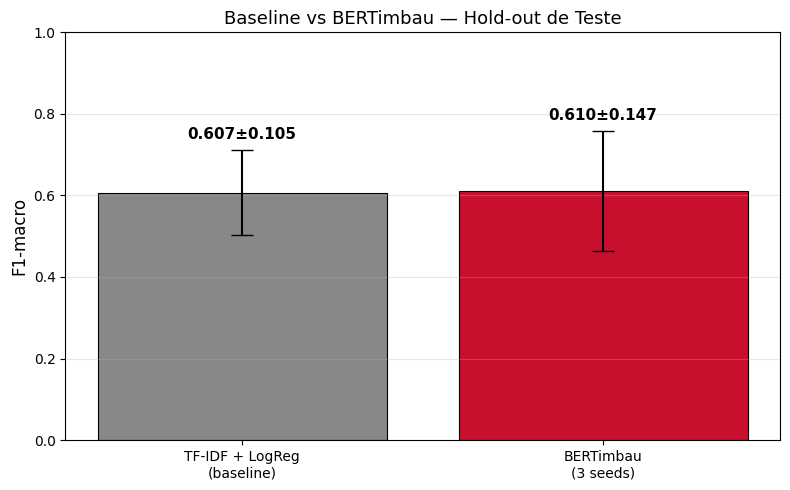

Salva: /content/drive/MyDrive/Agente Mecânico/resultados/bertimbau_vs_baseline.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

labels_ = ['TF-IDF + LogReg\n(baseline)', 'BERTimbau\n(3 seeds)']
vals    = [F1_BASELINE, df_res['f1_macro_teste'].mean()]
errs    = [0.105, df_res['f1_macro_teste'].std()]
cores   = ['#888888', '#C8102E']

bars = ax.bar(labels_, vals, yerr=errs, capsize=8,
              color=cores, edgecolor='black', linewidth=0.8)
for bar, v, e in zip(bars, vals, errs):
    ax.text(bar.get_x() + bar.get_width()/2, v + e + 0.02,
            f'{v:.3f}±{e:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_ylabel('F1-macro', fontsize=12)
ax.set_title('Baseline vs BERTimbau — Hold-out de Teste', fontsize=13)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

p2 = RESULTADOS_DIR / 'bertimbau_vs_baseline.png'
plt.savefig(p2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salva: {p2}')

---
## Seção 10 — Artefatos gerados

In [ ]:
print('ARTEFATOS GERADOS')
print('='*70)
print(f'\nModelo:    {MODELO_DIR}/')
print( '           config.json, model.safetensors (~420 MB), metadata.json')
print(f'\nResultados em CSV:')
for n in ['split_treino.csv','split_val.csv','split_teste.csv',
          'bertimbau_resultados_seeds.csv','bertimbau_por_variacao_linguistica.csv']:
    p = RESULTADOS_DIR / n
    if p.exists(): print(f'  {p}')
print(f'\nFiguras:')
for n in ['bertimbau_matriz_confusao.png','bertimbau_vs_baseline.png']:
    p = RESULTADOS_DIR / n
    if p.exists(): print(f'  {p}')
print(f'\nTexto:')
p = RESULTADOS_DIR / 'bertimbau_classification_report.txt'
if p.exists(): print(f'  {p}')
print('\n' + '='*70)
print('Próximo passo: 03_pipeline_integrado.ipynb')
print('  → detecta MODELO_DIR automaticamente e usa BERTimbau no lugar do baseline')

ARTEFATOS GERADOS

Modelo:    /content/drive/MyDrive/Agente Mecânico/modelos/bertimbau_mao_na_roda/
           config.json, model.safetensors (~420 MB), metadata.json

Resultados em CSV:
  /content/drive/MyDrive/Agente Mecânico/resultados/split_treino.csv
  /content/drive/MyDrive/Agente Mecânico/resultados/split_val.csv
  /content/drive/MyDrive/Agente Mecânico/resultados/split_teste.csv
  /content/drive/MyDrive/Agente Mecânico/resultados/bertimbau_resultados_seeds.csv
  /content/drive/MyDrive/Agente Mecânico/resultados/bertimbau_por_variacao_linguistica.csv

Figuras:
  /content/drive/MyDrive/Agente Mecânico/resultados/bertimbau_matriz_confusao.png
  /content/drive/MyDrive/Agente Mecânico/resultados/bertimbau_vs_baseline.png

Texto:
  /content/drive/MyDrive/Agente Mecânico/resultados/bertimbau_classification_report.txt

Próximo passo: 03_pipeline_integrado.ipynb
  → detecta MODELO_DIR automaticamente e usa BERTimbau no lugar do baseline
